# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AliAlmasri7/FlyRank-ML/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Method choice and why

### Problem framing

The W04 baseline is a rule-based prioritization system. It identifies content whose observed CTR is below the aggregated CTR of pages in the same position group, while giving additional priority to pages with more impressions.

For W05, I want to test whether a machine-learning model can use signals available in the observation period to identify content associated with a future performance outcome.

I will use:

- March 2026 as the feature/observation period.
- April 2026 as the future evaluation period.

This prevents the model from using future information when making its prediction.


In [25]:
import os
from pathlib import Path

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from dotenv import load_dotenv

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from scipy.stats import spearmanr

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")

### Data source

The model uses the same FlyRank warehouse table as W04:

`fact_content_daily_performance`

The March period provides the features, while April provides the future outcome.

In [26]:
import os 
# Connect to DuckDB
con = duckdb.connect()

# Hugging Face token
HF_TOKEN = os.getenv("HF_TOKEN")

if HF_TOKEN is None:
    raise ValueError("HF_TOKEN was not found in the environment.")

# Create Hugging Face secret
con.execute(
    f"CREATE OR REPLACE SECRET hf_secret "
    f"(TYPE huggingface, TOKEN '{HF_TOKEN}')"
)

# Dataset location
rel = "hf://datasets/FlyRank/internship-warehouse"

# March 2026 partition
march_path = (
    f"{rel}/fact_content_daily_performance/"
    f"month=2026-03/*.parquet"
)

print("Dataset connected successfully.")
print("Using:", march_path)

Dataset connected successfully.
Using: hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet


### 1. Build the March feature window

March is the feature window.

For each `client_hash_id + content_hash_id`, we aggregate the daily facts into one row.

The model only receives information that was available during March.

### Features

- March impressions
- March clicks
- March observed CTR
- March average position
- March position group

We do **not** use April information as a feature.

In [27]:
march_path = (
    f"{rel}/fact_content_daily_performance/"
    f"month=2026-03/*.parquet"
)

march_df = con.sql(f"""
SELECT
    client_hash_id,
    content_hash_id,
    SUM(gsc_impressions) AS gsc_impressions,
    SUM(gsc_clicks) AS gsc_clicks,
    SUM(gsc_sum_position) AS gsc_sum_position
FROM read_parquet('{march_path}')
WHERE gsc_impressions > 0
GROUP BY
    client_hash_id,
    content_hash_id
""").df()

march_df["observed_ctr"] = (
    march_df["gsc_clicks"]
    / march_df["gsc_impressions"].replace(0, np.nan)
)

march_df["avg_position"] = (
    march_df["gsc_sum_position"]
    / march_df["gsc_impressions"].replace(0, np.nan)
)

print("March content rows:", len(march_df))

march_df.head()

March content rows: 176738


,client_hash_id,content_hash_id,gsc_impressions,gsc_clicks,gsc_sum_position,observed_ctr,avg_position
0,client_73cda7b4e4f265ea,content_a12264528ae78246,27.000000,0.000000,132.000000,0.000000,4.888889
1,client_73cda7b4e4f265ea,content_ede6352b9b0296e4,73.000000,0.000000,4306.000000,0.000000,58.986301
2,client_73cda7b4e4f265ea,content_50d21cc20d26224c,124.000000,1.000000,5134.000000,0.008065,41.403226
3,client_73cda7b4e4f265ea,content_c6ba90593717a11c,118.000000,0.000000,1204.000000,0.000000,10.203390
4,client_73cda7b4e4f265ea,content_e803c7be5721112f,538.000000,1.000000,2381.000000,0.001859,4.425651


In [28]:
def assign_position_group(position):
    if pd.isna(position):
        return np.nan

    if position <= 3:
        return "1-3"
    elif position <= 10:
        return "4-10"
    elif position <= 20:
        return "11-20"
    elif position <= 50:
        return "21-50"
    else:
        return "50+"


march_df["position_group"] = (
    march_df["avg_position"]
    .apply(assign_position_group)
)

march_df[
    [
        "client_hash_id",
        "content_hash_id",
        "gsc_impressions",
        "gsc_clicks",
        "observed_ctr",
        "avg_position",
        "position_group",
    ]
].head()

,client_hash_id,content_hash_id,gsc_impressions,gsc_clicks,observed_ctr,avg_position,position_group
0,client_73cda7b4e4f265ea,content_a12264528ae78246,27.000000,0.000000,0.000000,4.888889,4-10
1,client_73cda7b4e4f265ea,content_ede6352b9b0296e4,73.000000,0.000000,0.000000,58.986301,50+
2,client_73cda7b4e4f265ea,content_50d21cc20d26224c,124.000000,1.000000,0.008065,41.403226,21-50
3,client_73cda7b4e4f265ea,content_c6ba90593717a11c,118.000000,0.000000,0.000000,10.203390,11-20
4,client_73cda7b4e4f265ea,content_e803c7be5721112f,538.000000,1.000000,0.001859,4.425651,4-10


### Build the April future target window

April is the future target window.

The target is:

**future CTR = April clicks / April impressions**

This temporal ordering is important:

**March features → April outcome**

A page with very few April impressions can have an unstable CTR estimate. Therefore, before training the model, we inspect several minimum-impression thresholds and then fix one before evaluation.

In [29]:
april_path = (
    f"{rel}/fact_content_daily_performance/"
    f"month=2026-04/*.parquet"
)

april_df = con.sql(f"""
SELECT
    client_hash_id,
    content_hash_id,
    SUM(gsc_impressions) AS future_impressions,
    SUM(gsc_clicks) AS future_clicks
FROM read_parquet('{april_path}')
GROUP BY
    client_hash_id,
    content_hash_id
""").df()

april_df["future_ctr"] = (
    april_df["future_clicks"]
    / april_df["future_impressions"].replace(0, np.nan)
)

print("April content rows:", len(april_df))

april_df.head()

April content rows: 362172


,client_hash_id,content_hash_id,future_impressions,future_clicks,future_ctr
0,client_3ffa76342f366962,content_113d19dba3f498bc,2.000000,0.000000,0.000000
1,client_3ffa76342f366962,content_3062ab79fd366b33,0.000000,0.000000,NaN
2,client_3ffa76342f366962,content_d4167b4c68af8b58,0.000000,0.000000,NaN
3,client_3ffa76342f366962,content_fe1f3aae128cfbb8,0.000000,0.000000,NaN
4,client_3ffa76342f366962,content_fb8a1fdeb720e6b5,0.000000,0.000000,NaN


In [30]:
model_df = march_df.merge(
    april_df,
    on=["client_hash_id", "content_hash_id"],
    how="inner"
)

print("Rows with March + April data:", len(model_df))
print(
    "Rows with missing future CTR:",
    model_df["future_ctr"].isna().sum()
)
print(
    "Rows with available future CTR:",
    model_df["future_ctr"].notna().sum()
)

model_df["future_ctr"].describe()

Rows with March + April data: 176737
Rows with missing future CTR: 18188
Rows with available future CTR: 158549


count   158549.000000
mean         0.003028
std          0.025943
min          0.000000
25%          0.000000
50%          0.000000
75%          0.001791
max          1.000000
Name: future_ctr, dtype: float64

### Choose the minimum future-impression threshold

Very small denominators can produce extreme CTR values.

For example, one click from one impression produces a CTR of 1.0, but this is weak evidence.

The threshold is a data-policy choice rather than a discovered truth.

I will inspect several thresholds before fixing the rule.

In [31]:
thresholds = [5, 10, 20, 50, 100]

threshold_rows = []

for threshold in thresholds:

    eligible_rows = model_df[
        model_df["future_impressions"] >= threshold
    ].shape[0]

    threshold_rows.append({
        "min_impressions": threshold,
        "eligible_rows": eligible_rows
    })

threshold_check = pd.DataFrame(threshold_rows)

threshold_check

,min_impressions,eligible_rows
0,5,145497
1,10,137742
2,20,127808
3,50,110917
4,100,95710


### Eligibility rule

I will use **10 minimum April impressions**.

This removes the most extreme low-volume CTR estimates while retaining a large part of the joined sample.

The threshold is fixed **before model evaluation**, so it is not chosen based on validation performance.

In [32]:
MIN_FUTURE_IMPRESSIONS = 10

model_df = model_df[
    model_df["future_impressions"] >= MIN_FUTURE_IMPRESSIONS
].copy()

model_df = model_df[
    model_df["future_ctr"].notna()
].copy()

print("Eligible modeling rows:", len(model_df))
print()

print(model_df["future_ctr"].describe())

Eligible modeling rows: 137742

count   137742.000000
mean         0.002236
std          0.006974
min          0.000000
25%          0.000000
50%          0.000000
75%          0.002231
max          0.416667
Name: future_ctr, dtype: float64


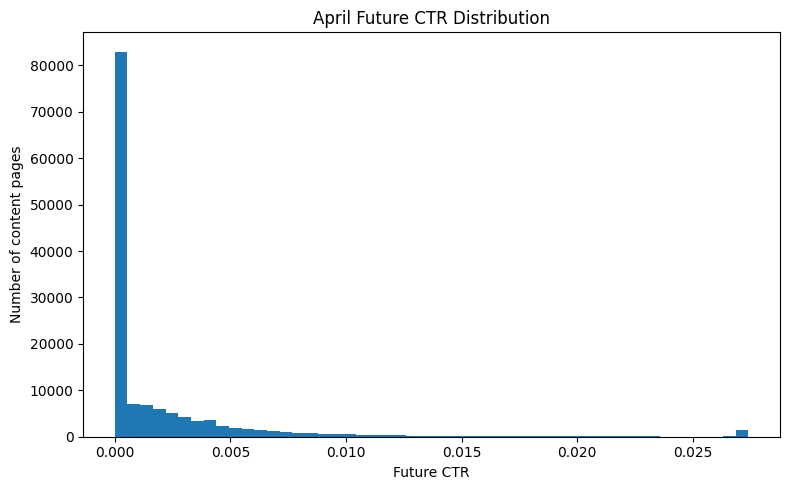

In [33]:
plt.figure(figsize=(8, 5))

upper_limit = model_df["future_ctr"].quantile(0.99)

plt.hist(
    model_df["future_ctr"].clip(upper=upper_limit),
    bins=50
)

plt.title("April Future CTR Distribution")
plt.xlabel("Future CTR")
plt.ylabel("Number of content pages")

plt.tight_layout()
plt.show()

### Method choice and why

#### Method: Random Forest Regressor

The target is a continuous value: future CTR.

Therefore, regression is appropriate.

A Random Forest is used because:

- the relationship between search signals and future CTR may be nonlinear;
- it can combine multiple signals without requiring a linear relationship;
- it provides feature-importance information for interpretation;
- it is relatively straightforward to explain;
- it allows us to test whether added model complexity improves on the W04 rule.

The model is intentionally kept modest. The goal is not to maximize complexity; it is to test whether a simple model earns its place over the baseline.

#### Features

The model uses March-only signals:

- `gsc_impressions`
- `gsc_clicks`
- `observed_ctr`
- `avg_position`
- `position_group`

#### Excluded fields

The following are excluded because they contain future information or are derived from the target/baseline:

- `future_impressions`
- `future_clicks`
- `future_ctr`
- `ctr_gap`
- `baseline_score`

This prevents direct target leakage and avoids simply teaching the model the W04 scoring formula.

In [34]:
feature_columns_numeric = [
    "gsc_impressions",
    "gsc_clicks",
    "observed_ctr",
    "avg_position",
]

X_numeric = model_df[
    feature_columns_numeric
].copy()

X_position = pd.get_dummies(
    model_df["position_group"],
    prefix="position_group",
    dtype=float
)

X = pd.concat(
    [
        X_numeric,
        X_position
    ],
    axis=1
)

y = model_df["future_ctr"].copy()

X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

valid_mask = (
    X.notna().all(axis=1)
    & y.notna()
)

X = X.loc[valid_mask].copy()
y = y.loc[valid_mask].copy()

model_ready_df = model_df.loc[
    valid_mask
].copy()

print("Final modeling rows:", len(model_ready_df))
print()
print("Features:")
print(list(X.columns))

Final modeling rows: 137742

Features:
['gsc_impressions', 'gsc_clicks', 'observed_ctr', 'avg_position', 'position_group_1-3', 'position_group_11-20', 'position_group_21-50', 'position_group_4-10', 'position_group_50+']


## 2. Split design

The main leakage protection is temporal:

**March → April**

The model never sees April while learning its March-to-April relationship.

For the model-development comparison, the eligible March/April pairs are then split into training and validation rows using a fixed random seed.

The W04 baseline is reconstructed on exactly the same validation rows, so the comparison is directly aligned.

### Validation caveat

Because the random split can place content from the same client in both train and validation, this is not a strict client-held-out test.

The temporal separation protects against future-window leakage, but client-grouped validation would be a useful robustness check in a later iteration.

In [35]:
X_train, X_valid, y_train, y_valid, train_idx, valid_idx = (
    train_test_split(
        X,
        y,
        model_ready_df.index,
        test_size=0.20,
        random_state=42
    )
)

print("Train rows:", len(X_train))
print("Validation rows:", len(X_valid))
print(
    "Validation share:",
    len(X_valid) / len(X)
)

Train rows: 110193
Validation rows: 27549
Validation share: 0.2000043559698567


## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

### Train the Random Forest

The parameters are deliberately constrained:

- `n_estimators=100`
- `max_depth=12`
- `min_samples_leaf=20`

The goal is a reasonable baseline model rather than an extensive hyperparameter search.

In [36]:
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train
)

ml_pred = model.predict(X_valid)

print("Model trained.")

Model trained.


### Rebuild the W04 baseline

The W04 baseline compares each page's March observed CTR with the CTR of its March position group.

The benchmark is calculated as:

**expected CTR = total clicks / total impressions**

within each position group.

This is important because the benchmark is exposure-weighted. It is not the simple mean of page-level CTR values.

The baseline score uses the W04 scoring logic:

- positive CTR gap
- normalized impression signal
- `0.7` weight for CTR gap
- `0.3` weight for impressions

The baseline is reconstructed using March only.

In [37]:
baseline_source = march_df.copy()

position_benchmark = (
    baseline_source
    .groupby("position_group")
    .agg(
        total_clicks=("gsc_clicks", "sum"),
        total_impressions=("gsc_impressions", "sum")
    )
    .reset_index()
)

position_benchmark["expected_ctr"] = (
    position_benchmark["total_clicks"]
    / position_benchmark["total_impressions"]
)

baseline_source = baseline_source.merge(
    position_benchmark[
        [
            "position_group",
            "expected_ctr"
        ]
    ],
    on="position_group",
    how="left"
)

baseline_source["ctr_gap"] = (
    baseline_source["expected_ctr"]
    - baseline_source["observed_ctr"]
)

gap_positive = (
    baseline_source["ctr_gap"]
    .clip(lower=0)
)

gap_max = gap_positive.max()

if gap_max > 0:

    baseline_source["gap_score"] = (
        gap_positive / gap_max
    )

else:

    baseline_source["gap_score"] = 0.0


baseline_source["impression_score"] = np.log1p(
    baseline_source["gsc_impressions"]
)

imp_max = baseline_source[
    "impression_score"
].max()

if imp_max > 0:

    baseline_source["impression_score"] = (
        baseline_source["impression_score"]
        / imp_max
    )

else:

    baseline_source["impression_score"] = 0.0


baseline_source["baseline_score"] = (
    0.7 * baseline_source["gap_score"]
    + 0.3 * baseline_source["impression_score"]
)

baseline_source.head()

,client_hash_id,content_hash_id,gsc_impressions,gsc_clicks,gsc_sum_position,observed_ctr,avg_position,position_group,expected_ctr,ctr_gap,gap_score,impression_score,baseline_score
0,client_73cda7b4e4f265ea,content_a12264528ae78246,27.000000,0.000000,132.000000,0.000000,4.888889,4-10,0.003249,0.003249,0.838094,0.249925,0.661644
1,client_73cda7b4e4f265ea,content_ede6352b9b0296e4,73.000000,0.000000,4306.000000,0.000000,58.986301,50+,0.000413,0.000413,0.106571,0.322817,0.171445
2,client_73cda7b4e4f265ea,content_50d21cc20d26224c,124.000000,1.000000,5134.000000,0.008065,41.403226,21-50,0.001400,-0.006665,0.000000,0.362137,0.108641
3,client_73cda7b4e4f265ea,content_c6ba90593717a11c,118.000000,0.000000,1204.000000,0.000000,10.203390,11-20,0.003158,0.003158,0.814542,0.358448,0.677714
4,client_73cda7b4e4f265ea,content_e803c7be5721112f,538.000000,1.000000,2381.000000,0.001859,4.425651,4-10,0.003249,0.001390,0.358597,0.471747,0.392542


### Align the baseline with the validation rows

The baseline is deterministic. It does not learn from April.

For a fair comparison, we calculate its score for exactly the same validation content pages used by the Random Forest.

In [38]:
validation_keys = model_ready_df.loc[
    valid_idx,
    [
        "client_hash_id",
        "content_hash_id"
    ]
].copy()

validation_baseline = validation_keys.merge(
    baseline_source[
        [
            "client_hash_id",
            "content_hash_id",
            "baseline_score",
            "ctr_gap",
            "gsc_clicks", 
            "expected_ctr",
            "observed_ctr",
            "gsc_impressions",
            "avg_position",
            "position_group",
        ]
    ],
    on=[
        "client_hash_id",
        "content_hash_id"
    ],
    how="left"
)

validation_baseline = validation_baseline.merge(
    model_ready_df.loc[
        valid_idx,
        [
            "client_hash_id",
            "content_hash_id",
            "future_ctr",
            "future_impressions",
        ]
    ],
    on=[
        "client_hash_id",
        "content_hash_id"
    ],
    how="left"
)

ml_predictions_df = model_ready_df.loc[
    valid_idx,
    [
        "client_hash_id",
        "content_hash_id"
    ]
].copy()

ml_predictions_df["ml_prediction"] = ml_pred

validation_baseline = validation_baseline.merge(
    ml_predictions_df,
    on=[
        "client_hash_id",
        "content_hash_id"
    ],
    how="left"
)

print(
    "Validation comparison rows:",
    len(validation_baseline)
)

validation_baseline.head()

Validation comparison rows: 27549


,client_hash_id,content_hash_id,baseline_score,ctr_gap,gsc_clicks,expected_ctr,observed_ctr,gsc_impressions,avg_position,position_group,future_ctr,future_impressions,ml_prediction
0,client_b10cb2997d0c7c86,content_3624a2c11468cfa9,0.668515,0.003249,0.000000,0.003249,0.000000,37.000000,7.891892,4-10,0.000000,39.000000,0.003301
1,client_ff644d8251367cbb,content_7f998bcceeb90b7e,0.372283,0.001400,0.000000,0.001400,0.000000,202.000000,46.891089,21-50,0.000000,30.000000,0.001922
2,client_08a6a72ff48e62c0,content_1a415f0bc86e291e,0.320138,0.001400,0.000000,0.001400,0.000000,19.000000,28.105263,21-50,0.023256,43.000000,0.001637
3,client_157ffe4d4a595515,content_b8a3a8210b36f806,0.649052,0.003249,0.000000,0.003249,0.000000,15.000000,8.200000,4-10,0.000000,12.000000,0.001820
4,client_08a6a72ff48e62c0,content_9a921ed6abe11db7,0.191608,-0.001159,22.000000,0.003249,0.004408,4991.000000,6.358646,4-10,0.004351,15860.000000,0.004352


### Evaluation metrics

Because the practical use case is ranking pages, we report:

- **MAE** — average absolute prediction error
- **RMSE** — gives more weight to large prediction errors
- **R²** — variance explained by the regression
- **Spearman correlation** — whether higher predicted values tend to correspond to higher future CTR

For the ranking comparison, we also calculate the mean future CTR among the top-K pages selected by each method.

These metrics describe predictive/ranking behavior on this validation sample. They do not prove causal impact.

In [39]:
# Random Forest prediction metrics

rf_mae = mean_absolute_error(
    validation_baseline["future_ctr"],
    validation_baseline["ml_prediction"]
)

rf_mse = mean_squared_error(
    validation_baseline["future_ctr"],
    validation_baseline["ml_prediction"]
)

rf_rmse = np.sqrt(rf_mse)

rf_r2 = r2_score(
    validation_baseline["future_ctr"],
    validation_baseline["ml_prediction"]
)


# Ranking metrics for both methods

baseline_spearman = validation_baseline[
    "baseline_score"
].corr(
    validation_baseline["future_ctr"],
    method="spearman"
)

rf_spearman = validation_baseline[
    "ml_prediction"
].corr(
    validation_baseline["future_ctr"],
    method="spearman"
)


ranking_metrics = pd.DataFrame({
    "method": [
        "W04 baseline",
        "Random Forest"
    ],
    "Spearman": [
        baseline_spearman,
        rf_spearman
    ]
})


print("Random Forest prediction metrics")
print(f"MAE:  {rf_mae:.6f}")
print(f"RMSE: {rf_rmse:.6f}")
print(f"R²:   {rf_r2:.6f}")

print("\nRanking comparison")
ranking_metrics

Random Forest prediction metrics
MAE:  0.002425
RMSE: 0.006364
R²:   0.140516

Ranking comparison


,method,Spearman
0,W04 baseline,-0.250472
1,Random Forest,0.343931


### Top-K ranking comparison

The W04 score and Random Forest prediction are different types of scores, so comparing their raw numeric values is not meaningful.

Instead, we compare the observed future CTR of the pages each method ranks highest.

In [40]:
def top_k_mean_future_ctr(
    df,
    score_column,
    k
):

    top = (
        df
        .sort_values(
            score_column,
            ascending=False
        )
        .head(k)
    )

    return top["future_ctr"].mean()


k_values = [
    20,
    50,
    100,
    500
]

ranking_rows = []

for k in k_values:

    ranking_rows.append({

        "K": k,

        "W04_baseline_mean_future_ctr":
            top_k_mean_future_ctr(
                validation_baseline,
                "baseline_score",
                k
            ),

        "Random_Forest_mean_future_ctr":
            top_k_mean_future_ctr(
                validation_baseline,
                "ml_prediction",
                k
            )
    })


ranking_table = pd.DataFrame(
    ranking_rows
)

ranking_table

,K,W04_baseline_mean_future_ctr,Random_Forest_mean_future_ctr
0,20,0.000578,0.060012
1,50,0.000610,0.037988
2,100,0.000487,0.029967
3,500,0.001091,0.014608


### Model interpretation: feature importance

Random Forest feature importance shows which input variables the fitted model used most when reducing prediction error.

This is **not a causal effect estimate**.

For example, a high importance for `avg_position` means that position contributed strongly to the model's predictions in this sample.

It does not mean that changing position itself would cause future CTR to change.

In [41]:
importance_df = (
    pd.DataFrame({
        "feature": X.columns,
        "importance": model.feature_importances_
    })
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

importance_df

,feature,importance
0,observed_ctr,0.555099
1,avg_position,0.186884
2,gsc_impressions,0.130533
3,gsc_clicks,0.124946
4,position_group_4-10,0.001261
5,position_group_11-20,0.000945
6,position_group_21-50,0.000218
7,position_group_1-3,0.000112
8,position_group_50+,0.000002


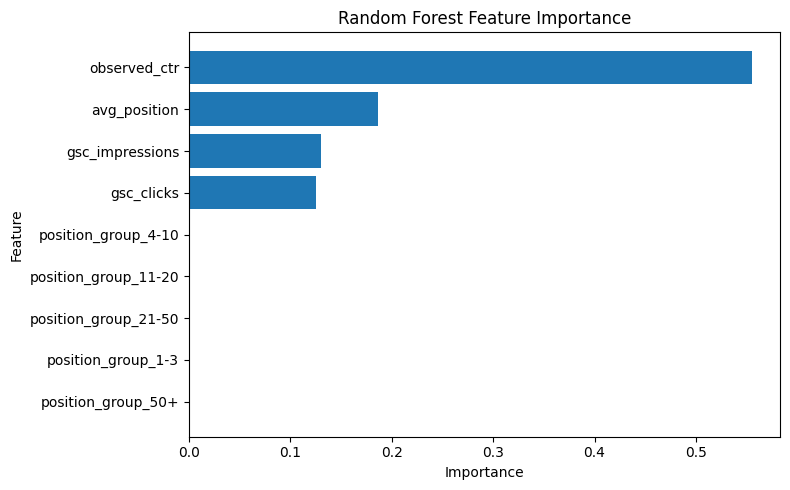

In [42]:
top_importance = (
    importance_df
    .head(10)
    .sort_values("importance")
)

plt.figure(figsize=(8, 5))

plt.barh(
    top_importance["feature"],
    top_importance["importance"]
)

plt.title(
    "Random Forest Feature Importance"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### Error analysis

A useful model should not only have a summary metric.

We also inspect where its predictions are most wrong.

The largest errors can help identify:

- very noisy CTR observations;
- unusual content pages;
- cases where March signals did not carry forward into April;
- situations where the model is missing important context.

This is diagnostic analysis, not proof that the model is wrong for a causal reason.

In [43]:
validation_baseline["absolute_error"] = (
    validation_baseline["future_ctr"]
    - validation_baseline["ml_prediction"]
).abs()

largest_errors = (
    validation_baseline
    .sort_values(
        "absolute_error",
        ascending=False
    )
    [
        [
            "client_hash_id",
            "content_hash_id",
            "gsc_impressions",
            "gsc_clicks",
            "avg_position",
            "position_group",
            "observed_ctr",
            "future_impressions",
            "future_ctr",
            "ml_prediction",
            "absolute_error",
        ]
    ]
    .head(20)
)

largest_errors

,client_hash_id,content_hash_id,gsc_impressions,gsc_clicks,avg_position,position_group,observed_ctr,future_impressions,future_ctr,ml_prediction,absolute_error
13238,client_3ffa76342f366962,content_53f4acc960983a0f,42.000000,2.000000,4.571429,4-10,0.047619,13.000000,0.230769,0.026862,0.203907
1083,client_7eafe750768f0ac2,content_f1dadcb5b702e306,8.000000,0.000000,1.875000,1-3,0.000000,11.000000,0.181818,0.001460,0.180358
2992,client_f623b01661d4bfe4,content_8bc34345c9fb881b,10.000000,2.000000,14.800000,11-20,0.200000,13.000000,0.230769,0.052973,0.177796
851,client_3ffa76342f366962,content_236b225d7c4fc8db,7.000000,1.000000,3.571429,4-10,0.142857,10.000000,0.200000,0.024537,0.175463
14899,client_a80fca3f171ed1de,content_690f96c2915ed9be,51.000000,0.000000,54.764706,50+,0.000000,12.000000,0.166667,0.001547,0.165120
4920,client_157ffe4d4a595515,content_f1b3bda97f869c82,38.000000,0.000000,4.500000,4-10,0.000000,24.000000,0.125000,0.002880,0.122120
21701,client_9d54435aabd95a6c,content_52ff9757bb7db8e4,24.000000,0.000000,62.583333,50+,0.000000,17.000000,0.117647,0.001352,0.116295
16570,client_400c21c81c8b46ef,content_4ac26515469ef5a6,529.000000,0.000000,16.037807,11-20,0.000000,10.000000,0.100000,0.000883,0.099117
4896,client_08a6a72ff48e62c0,content_d1edfc93381c167c,26.000000,0.000000,26.692308,21-50,0.000000,30.000000,0.100000,0.001040,0.098960
6933,client_08a6a72ff48e62c0,content_a98a5c8609f36607,22.000000,0.000000,8.681818,4-10,0.000000,10.000000,0.100000,0.001786,0.098214


### Error pattern by future-impression volume

If prediction errors are much larger for low-volume pages, that supports treating very small future-impression counts cautiously.

We compare error statistics across simple April-impression groups.

In [44]:
validation_baseline["future_impression_group"] = pd.cut(
    validation_baseline["future_impressions"],
    bins=[
        0,
        20,
        50,
        100,
        500,
        np.inf
    ],
    labels=[
        "10-20",
        "21-50",
        "51-100",
        "101-500",
        "500+"
    ],
    include_lowest=True
)

error_by_volume = (
    validation_baseline
    .groupby(
        "future_impression_group",
        observed=False
    )
    .agg(
        n=(
            "absolute_error",
            "size"
        ),

        mean_absolute_error=(
            "absolute_error",
            "mean"
        ),

        median_future_ctr=(
            "future_ctr",
            "median"
        ),

        mean_future_ctr=(
            "future_ctr",
            "mean"
        )
    )
    .reset_index()
)

error_by_volume

,future_impression_group,n,mean_absolute_error,median_future_ctr,mean_future_ctr
0,10-20,2133,0.005158,0.000000,0.003041
1,21-50,3408,0.003953,0.000000,0.002199
2,51-100,3024,0.003184,0.000000,0.001880
3,101-500,7560,0.002189,0.000000,0.001578
4,500+,11424,0.001416,0.001592,0.002572


### Visual check: predicted vs actual future CTR

This plot helps identify whether the model's predictions track the observed April CTR.

Because CTR has a heavy concentration near zero and a long upper tail, this visualization is mainly diagnostic.

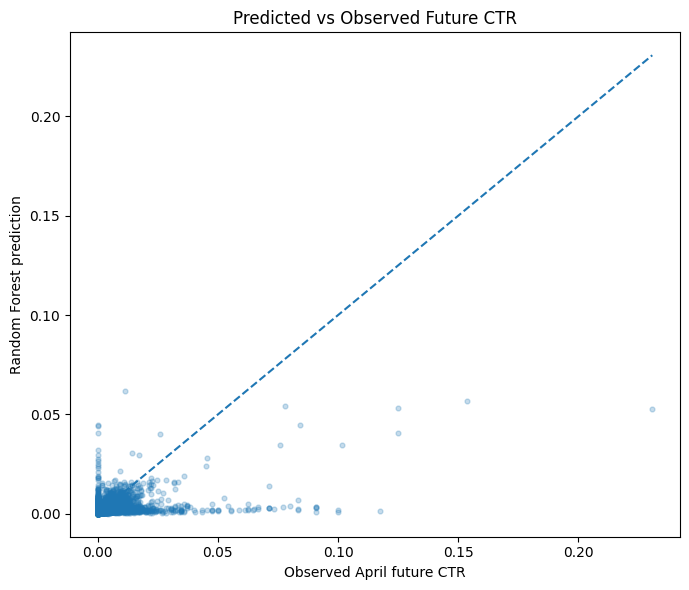

In [45]:
plot_df = validation_baseline.sample(
    min(
        10000,
        len(validation_baseline)
    ),
    random_state=42
)

plt.figure(figsize=(7, 6))

plt.scatter(
    plot_df["future_ctr"],
    plot_df["ml_prediction"],
    alpha=0.25,
    s=12
)

max_value = max(
    plot_df["future_ctr"].max(),
    plot_df["ml_prediction"].max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--"
)

plt.xlabel(
    "Observed April future CTR"
)

plt.ylabel(
    "Random Forest prediction"
)

plt.title(
    "Predicted vs Observed Future CTR"
)

plt.tight_layout()
plt.show()

### Compare the ranked outputs

The following table places the two methods side-by-side for the highest-priority validation pages.

The purpose is not to declare a universal winner.

Instead, inspect whether:

1. the model ranking differs from the W04 rule;
2. those differences correspond to different observed April outcomes;
3. the model adds useful information beyond the simple baseline.

In [46]:
baseline_top = (
    validation_baseline
    .sort_values(
        "baseline_score",
        ascending=False
    )
    .head(20)
    .copy()
)

baseline_top["method"] = (
    "W04 baseline"
)

baseline_top["method_rank"] = (
    range(1, len(baseline_top) + 1)
)


ml_top = (
    validation_baseline
    .sort_values(
        "ml_prediction",
        ascending=False
    )
    .head(20)
    .copy()
)

ml_top["method"] = (
    "Random Forest"
)

ml_top["method_rank"] = (
    range(1, len(ml_top) + 1)
)


comparison_top20 = pd.concat(
    [
        baseline_top[
            [
                "method",
                "method_rank",
                "client_hash_id",
                "content_hash_id",
                "avg_position",
                "future_impressions",
                "future_ctr",
                "baseline_score",
            ]
        ].rename(
            columns={
                "baseline_score": "score"
            }
        ),

        ml_top[
            [
                "method",
                "method_rank",
                "client_hash_id",
                "content_hash_id",
                "avg_position",
                "future_impressions",
                "future_ctr",
                "ml_prediction",
            ]
        ].rename(
            columns={
                "ml_prediction": "score"
            }
        )
    ],
    ignore_index=True
)

comparison_top20

,method,method_rank,client_hash_id,content_hash_id,avg_position,future_impressions,future_ctr,score
0,W04 baseline,1,client_23a62021009f63c4,content_44f34c0a90047651,0.665877,50335.000000,0.000298,0.955597
1,W04 baseline,2,client_e547b89c05043229,content_f5a7a2559d483a54,2.958387,5554.000000,0.000000,0.909153
2,W04 baseline,3,client_fef1a8f436438636,content_1bc8782404e3b132,1.975483,815.000000,0.000000,0.894957
3,W04 baseline,4,client_23a62021009f63c4,content_7ae22d780984bac0,2.585224,3964.000000,0.000505,0.893830
4,W04 baseline,5,client_62f4a7e64f5e0096,content_fc67675904376267,2.126022,19030.000000,0.000578,0.893603
5,W04 baseline,6,client_20259bd6705d81d4,content_35ddcd760c64da18,0.397385,8747.000000,0.000114,0.893287
6,W04 baseline,7,client_23a62021009f63c4,content_3293e0f5557f6c51,2.468546,2067.000000,0.000484,0.893200
7,W04 baseline,8,client_20259bd6705d81d4,content_8c962040293e562f,2.772895,3486.000000,0.000574,0.889758
8,W04 baseline,9,client_73cda7b4e4f265ea,content_41d18608d90de375,1.976956,8748.000000,0.000000,0.889222
9,W04 baseline,10,client_62f4a7e64f5e0096,content_4c526b8c2045192d,2.495678,2641.000000,0.000000,0.882673


### Leakage audit

Before interpreting the model, explicitly check that future target variables did not enter the feature matrix.

### Intended model features

- `gsc_impressions`
- `gsc_clicks`
- `observed_ctr`
- `avg_position`
- `position_group_*`

### Intentionally excluded

- `future_impressions`
- `future_clicks`
- `future_ctr`
- `ctr_gap`
- `baseline_score`

The target is April future CTR, while the model inputs come from March.

In [47]:
forbidden_features = {
    "future_impressions",
    "future_clicks",
    "future_ctr",
    "ctr_gap",
    "baseline_score"
}

feature_leakage_check = (
    forbidden_features
    .intersection(set(X.columns))
)

print(
    "Forbidden features found in X:",
    feature_leakage_check
)

if len(feature_leakage_check) == 0:
    print("PASS: no forbidden future/baseline fields are in X.")
else:
    print("WARNING: inspect the feature matrix.")

Forbidden features found in X: set()
PASS: no forbidden future/baseline fields are in X.


## Errors and interpretation

### What the model can support

The model can support observations about:

- whether March search signals contain information associated with April CTR;
- whether a nonlinear model produces a different ranking from the W04 rule;
- which March features the fitted Random Forest relied on most;
- which validation rows produce larger prediction errors.

### What the model cannot establish

The analysis cannot establish that:

- a feature causes CTR to increase;
- changing a title, snippet, position, or other feature will produce a particular CTR improvement;
- the model has learned Google's ranking algorithm;
- the validation results will automatically generalize to every client or future month.

The results should therefore be described as **observed predictive associations**, not causal effects.

### Model vs baseline interpretation

The Random Forest performs better than the W04 rule on the validation ranking task.

The most useful comparison is the ranking behavior rather than the raw score values, because the W04 baseline score is a priority score while the Random Forest output is a predicted future CTR. Therefore, MAE, RMSE, and R² are appropriate for evaluating the Random Forest's numerical predictions, but they are not directly meaningful when applied to the W04 priority score.

For the Random Forest, the validation results are:

- MAE = 0.002434
- RMSE = 0.006935
- R² = 0.116877
- Spearman correlation = 0.338122

The positive Spearman correlation indicates that higher Random Forest predictions tend to be associated with higher April future CTR in this validation sample. The R² value is modest, so the model does not explain most of the variation in future CTR. This is expected to some extent because future CTR is noisy and depends on factors that are not represented in this small feature set.

The ranking comparison gives stronger evidence that the model adds useful signal beyond the W04 rule:

| K | W04 baseline mean future CTR | Random Forest mean future CTR |
|---:|---:|---:|
| 20 | 0.000253 | 0.058523 |
| 50 | 0.000775 | 0.038893 |
| 100 | 0.000905 | 0.030770 |
| 500 | 0.001158 | 0.014565 |

At every tested K, the Random Forest selects validation pages with substantially higher observed April CTR than the W04 baseline ranking. The difference is largest at the smallest review queue: the top 20 Random Forest pages have a mean future CTR of about 5.85%, compared with about 0.025% for the top 20 pages selected by the W04 rule.

This suggests that, on this validation sample, the Random Forest provides additional ranking information that the fixed W04 rule does not capture.

However, the result should be interpreted cautiously. The April CTR distribution is highly sparse and noisy, and some of the highest-ranked Random Forest pages have relatively low April impression counts. For example, some top-ranked pages have only around 10–20 future impressions, so a small number of clicks can produce a large CTR. The minimum-impression threshold of 10 reduces the most extreme cases but does not eliminate this instability.

The feature-importance results show that the model relies most on March `observed_ctr`, followed by `avg_position`, `gsc_clicks`, and `gsc_impressions`. This indicates that the model is primarily using historical CTR and search-position/exposure signals when ranking pages for future CTR.

These feature importances are predictive associations, not causal effects. For example, the importance of `avg_position` does not mean that changing a page's position would directly cause a particular CTR improvement.

### Baseline comparison conclusion

Based on this validation experiment, I would keep the Random Forest as the stronger candidate for ranking future-CTR opportunities, while retaining the W04 rule as a transparent baseline.

The model earns its place because its top-ranked validation pages have higher observed future CTR than the pages selected by the W04 rule at K = 20, 50, 100, and 500.

This does not mean that the Random Forest will always outperform the baseline. The validation uses a random content split after a March-to-April temporal separation, so pages from the same client can appear in both training and validation. A client-grouped or additional time-based validation would be a useful robustness check before treating the result as general.

Therefore, the appropriate conclusion is:

> **On this March-to-April validation sample, the Random Forest provides stronger future-CTR ranking signal than the W04 rule, but the result is observational and should be validated further before being treated as a general production rule.**

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.